# 01 — Data Exploration

Inspect TinyStories, token distributions, and validate the `.bin` files
produced by `DataPrepPipeline`.  Run `make prep` before this notebook.

In [1]:
import sys
sys.path.insert(0, '../..')  # make src/ importable from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import tiktoken
from datasets import load_dataset
from pathlib import Path

In [2]:
# ── Load a sample of TinyStories ──────────────────────────────────────────
ds = load_dataset('roneneldan/TinyStories', split='train[:1000]')
print(f'Loaded {len(ds)} examples')
print('\nSample story:')
print(ds[0]['text'][:300])

Loaded 1000 examples

Sample story:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and 


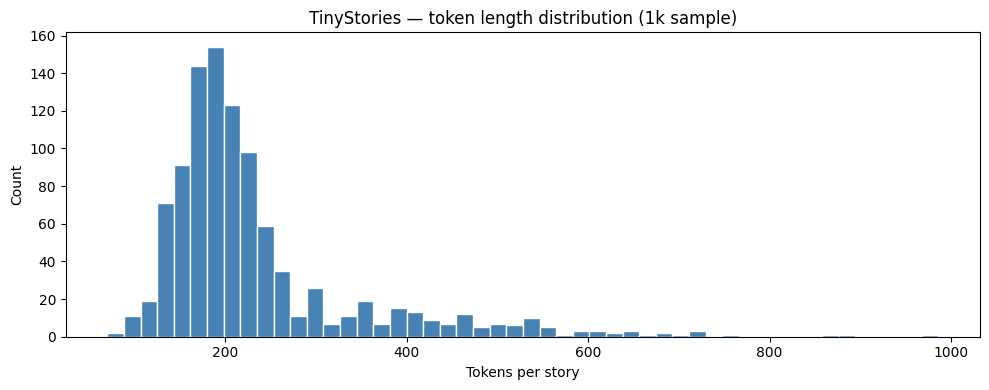

Mean: 234  |  Median: 199  |  Max: 986


In [3]:
# ── Token length distribution ─────────────────────────────────────────────
enc = tiktoken.get_encoding('gpt2')
lengths = [len(enc.encode_ordinary(ex['text'])) for ex in ds]

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Tokens per story')
plt.ylabel('Count')
plt.title('TinyStories — token length distribution (1k sample)')
plt.tight_layout()
plt.show()

print(f'Mean: {np.mean(lengths):.0f}  |  Median: {np.median(lengths):.0f}  '
      f'|  Max: {max(lengths)}')

In [4]:
# ── Validate .bin files ───────────────────────────────────────────────────
data_dir = Path('../../data')

for fname in ('train.bin', 'validation.bin'):
    p = data_dir / fname
    if not p.exists():
        print(f'MISSING: {p}  (run make prep first)')
        continue
    arr = np.memmap(str(p), dtype=np.uint16, mode='r')
    print(f'{fname}: {len(arr):,} tokens | '
          f'min={arr.min()} max={arr.max()} dtype={arr.dtype}')

train.bin: 471,872,517 tokens | min=0 max=50255 dtype=uint16
validation.bin: 4,743,928 tokens | min=0 max=50255 dtype=uint16
